In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Local packages
from etc.hamiltonian import Hamiltonian
from etc_utils.graph_models import *
from etc_utils.phase_diagrams import *

### Hamiltonian Equation
 We pretend to find the minimun for a given set of nodes k and parameters $\mu/\gamma$

$$
H(S) = \sum_{j<i}-\mu A_{ij} s_i s_j + \gamma \frac{s_i s_j (1-A_{ij})}{d_{i,j}²}
$$


### Import all graphs examples
Once this is predifine we upload the example graphs 

In [2]:
Gs = get_graphs_list()

In [3]:
def plot_phase_diagram(result: dict):
    if not result:
        raise ValueError("The result dictionary is empty.")

    k_values = list(result.keys())
    if not all(isinstance(k, (int, float)) for k in k_values):
        raise ValueError("Keys of the result dictionary must be numeric (e.g., int or float).")

    scale_values = list(result[k_values[0]].keys())
    if not all(isinstance(scale, (int, float)) for scale in scale_values):
        raise ValueError("Scale values in the result dictionary must be numeric (e.g., int or float).")

    mu_gamma_ratios = []
    hmin_values = []
    for k in k_values:
        for scale in scale_values:
            ratio, hmin = result[k][scale]
            mu_gamma_ratios.append(ratio)
            hmin_values.append(hmin)

    # Reshape data for heatmap
    try:
        mu_gamma_ratios = np.array(mu_gamma_ratios).reshape(len(k_values), len(scale_values))
        hmin_values = np.array(hmin_values).reshape(len(k_values), len(scale_values))
    except ValueError as e:
        raise ValueError("Mismatch in the dimensions of the result data. Ensure the data is consistent.") from e

    # Plot the phase diagram
    plt.figure(figsize=(10, 6))
    plt.imshow(hmin_values, aspect='auto', origin='lower',
               extent=[mu_gamma_ratios.min(), mu_gamma_ratios.max(),
                       min(k_values), max(k_values)], cmap='viridis')
    plt.colorbar(label='H_min')
    plt.xlabel('$\mu / \gamma$')
    plt.ylabel('$k$')
    plt.title('Phase Diagram')
    plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7804/895672755.py:34: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu / \gamma$')


1. First example
## Barbell graph (c=25, p=5)
* Nodes: $n=25$
* Edges: $e = 96$
##### Is the composition of 2 chiques connected by a line

Uncomment the line below to visualize the graph

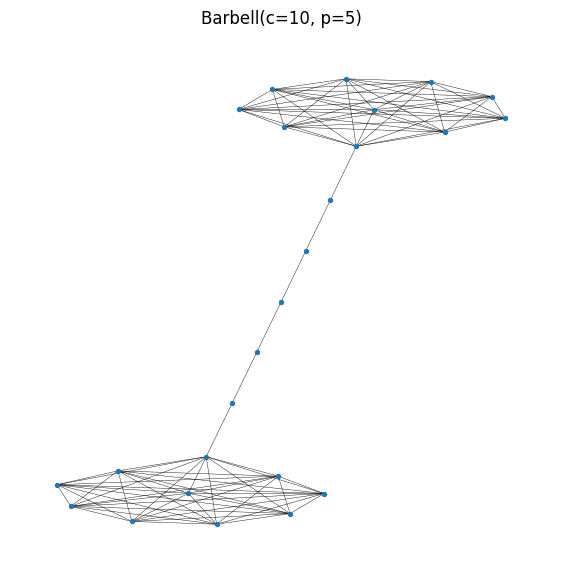

In [4]:
show_graph(Gs[0][1], title=Gs[0][0])

### Hamiltonian and graph atributes
$$\mu = 1 - \rho$$
where $\rho$ is
$$\rho = \frac{2e}{n(n-1)}$$

In [5]:
H1 = Hamiltonian(Gs[0][1])
# parameter mu predefined
mu=H1.mu_density_aware(G=Gs[0][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[0][1]))
# Inverse of distance matrix upper triangle
D2 = H1.Dinv2_triu

In [6]:
G1_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H1,
    mu=mu,
    kmax=int(7),
    scale_max=int(24),
    scale_steps=1,
    k_steps=1
)

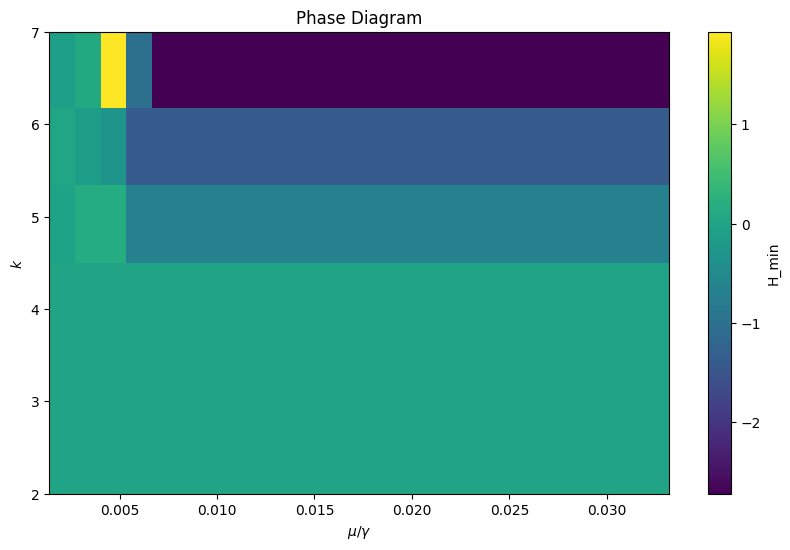

In [7]:
plot_phase_diagram(G1_pd)

In [7]:
#save values of G1_pd
np.save('G1_pd.npy', G1_pd)

In [ ]:
G1_pd = np.load('G1_pd.npy', allow_pickle=True)

In [ ]:
# Compute gradients to identify critical points
hmin_gradients = np.gradient(hmin_values, axis=0)
critical_points = np.abs(hmin_gradients) > np.percentile(np.abs(hmin_gradients), 95)  # Top 5% changes

# Overlay critical points on the phase diagram
plt.figure(figsize=(10, 6))
plt.imshow(hmin_values, aspect='auto', origin='lower',
           extent=[mu_gamma_ratios.min(), mu_gamma_ratios.max(),
                  min(k_values), max(k_values)], cmap='viridis')
plt.colorbar(label='H_min')
plt.xlabel('$\mu / \gamma$')
plt.ylabel('$k$')
plt.title('Phase Diagram with Critical Points')

# Highlight critical points
critical_k, critical_mu_gamma = np.where(critical_points)
plt.scatter(mu_gamma_ratios[critical_k, critical_mu_gamma],
            np.array(k_values)[critical_k], color='red', s=10, label='Critical Points')
plt.legend()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6226/1780319394.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu / \gamma$')
/tmp/ipykernel_6226/1780319394.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu / \gamma$')


NameError: name 'hmin_values' is not defined

2. Second Example
## Balance Tree (ramifications=3, height=4)
* Nodes: $n = 121$
* Edges: $e = 120$
##### The left and right subtrees of any node are the same height

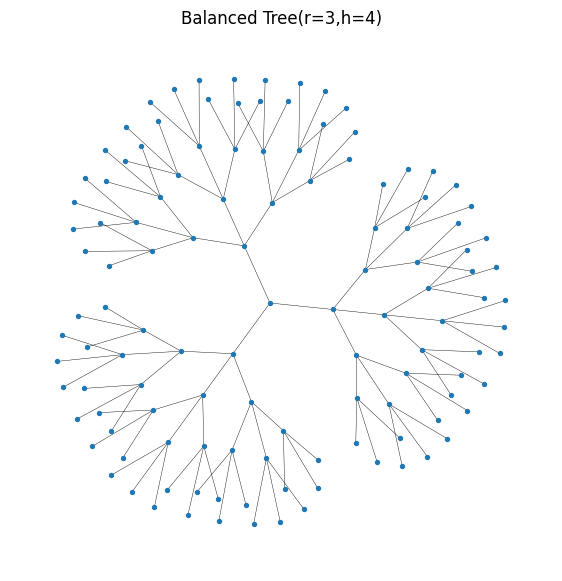

In [ ]:
show_graph(Gs[4][1], title=Gs[4][0])

## Random Partition communities
* Nodes: $n = 45$
* Edges: $e = 283$
#### A graph of communities with sizes defined by s in sizes. 

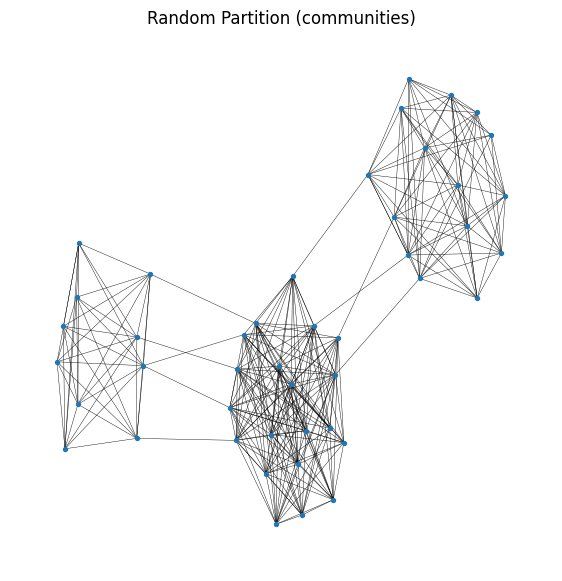

In [18]:
show_graph(Gs[7][1], title=Gs[7][0])

In [21]:
H7 = Hamiltonian(Gs[7][1])
# parameter mu predefined
mu=H7.mu_density_aware(G=Gs[7][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[7][1]))
# Inverse of distance matrix upper triangle
D2 = H7.Dinv2_triu

In [22]:
G7_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H7,
    mu=mu,
    kmax=int(15),
    scale_max=int(15),
    scale_steps=1,
    k_steps=1
)

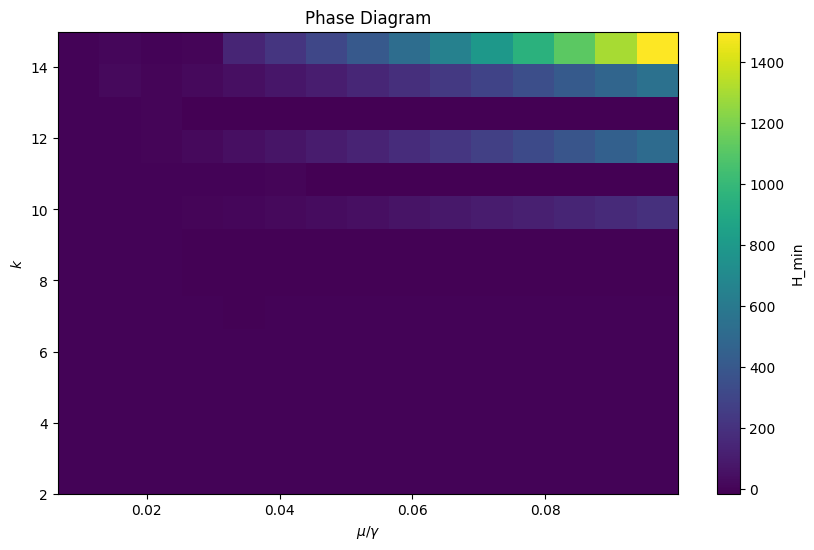

In [23]:
plot_phase_diagram(G7_pd)

## Erdos-Renyi (n=80, p=0.05)
* Nodes: $n = 80$
* Edges: $e = 156$
##### A random graph which connects each pair of nodes {i,j} with probability p, independent

In [24]:
H6 = Hamiltonian(Gs[6][1])
# parameter mu predefined
mu=H6.mu_density_aware(G=Gs[6][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[6][1]))
# Inverse of distance matrix upper triangle
D2 = H6.Dinv2_triu

In [25]:
G6_pd = phase_diagram_values(
    A=A,
    D2=D2,
    Hamiltonian=H6,
    mu=mu,
    kmax=int(35),
    scale_max=int(35),
    scale_steps=1,
    k_steps=1
)

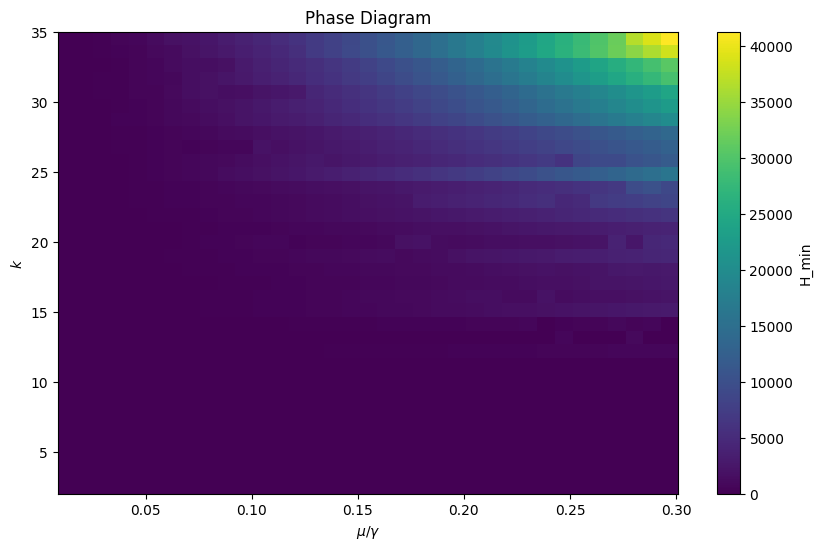

In [26]:
plot_phase_diagram(G6_pd)

## 6D Regular (nodes=50, degree=6)
* Nodes: $n = 50$
* Edges: $e = 150$
##### Regular graph with 50 nodes where all nodes have degree 6

In [ ]:
H17 = Hamiltonian(Gs[-3][1])
# parameter mu predefined
mu=H17.mu_density_aware(G=Gs[-3][1])
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[-3][1]))
# Inverse of distance matrix upper triangle
D2 = H17.Dinv2_triu